# Section 1: Foundations of Supervised Learning

Supervised learning is the process of learning a mapping function $f(X)$ from input features $X$ to a known target output $y$. The algorithm is "supervised" because we provide it with a ground-truth dataset where the correct answers are already known. The goal is to minimize the error between the model's predictions $\hat{y}$ and the actual labels $y$ so that the model can generalize to unseen data.

Supervised learning branches into two primary categories based on the nature of the target variable $y$:
1. **Regression:** The target variable is continuous (e.g., temperature, stock price, or `Tool wear [min]`).
2. **Classification:** The target variable is discrete or categorical (e.g., spam/not spam, or `Machine failure`).

# Import All liberaries 


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 4. Library Architecture & Tooling Justification

Before writing the execution code, it is important to understand the software stack powering this model. Below is a breakdown of every library imported, what its core function is, and exactly why it is required for this specific notebook.

### Data Manipulation
**`pandas` (pd)**
* **What it is:** The foundational data manipulation library in Python, built on top of C and Cython for speed.
* **What it does:** It provides the `DataFrame` object, which represents data in a 2D tabular format (rows and columns), similar to an SQL table or Excel sheet.
* **Why we use it here:** We need it to fetch the raw CSV dataset directly from the GitHub URL, drop irrelevant identifier columns (like `UDI`, `Product ID`), and separate our features ($X$) from our target ($y$).

**`numpy` (np)**
* **What it is:** The core library for scientific computing in Python.
* **What it does:** It provides support for large, multi-dimensional arrays and matrices, along with a massive collection of high-level mathematical functions.
* **Why we use it here:** Under the hood, `pandas` and `scikit-learn` rely entirely on `numpy` arrays. We will explicitly use it to calculate the square root of our Mean Squared Error to get the RMSE (Root Mean Squared Error) metric.

---

### Data Visualization
**`matplotlib.pyplot` (plt) & `seaborn` (sns)**
* **What they are:** `matplotlib` is the base plotting engine in Python. `seaborn` is a high-level API wrapper built on top of `matplotlib` that makes statistical graphics visually appealing and easier to write.
* **What they do:** They generate static, animated, and interactive visualizations.
* **Why we use them here:** After our Linear Regression model makes predictions, we need to verify its mathematical assumptions. We will use these libraries to plot a scatter plot of **Actual vs. Predicted values** and a **Residual Plot** to check for homoscedasticity (equal variance of errors).

---

### Machine Learning Framework (`scikit-learn`)

**`train_test_split`**
* **What it is:** A utility function from the `model_selection` module.
* **What it does:** It randomly shuffles the dataset and slices it into two distinct sets: a training set and a testing set.
* **Why we use it here:** To prevent "data leakage" and overfitting. We will train our Linear Regression model on 80% of the data, and test its accuracy on a hidden 20% to prove it can generalize to new, unseen machine data.

**`StandardScaler`**
* **What it is:** A data transformation tool from the `preprocessing` module.
* **What it does:** It standardizes features by removing the mean and scaling to unit variance ($z = \frac{x - \mu}{\sigma}$).
* **Why we use it here:** Our features have drastically different scales (e.g., `Rotational speed [rpm]` is in the thousands, while `Torque [Nm]` is in the tens). While Linear Regression is technically scale-invariant, scaling ensures numerical stability during matrix calculations and prepares our pipeline for algorithms that strictly require scaling (like Ridge/Lasso).

**`LinearRegression`**
* **What it is:** The actual algorithm class from the `linear_model` module.
* **What it does:** It uses Ordinary Least Squares (OLS) to calculate the optimal $\theta$ weights that minimize the residual sum of squares between the observed targets and the predicted targets.
* **Why we use it here:** This is the engine of this specific notebook. We instantiate this class, `.fit()` it to our training data, and call `.predict()` to estimate tool wear.

**`mean_squared_error`, `mean_absolute_error`, `r2_score`**
* **What they are:** Mathematical scoring functions from the `metrics` module.
* **What they do:** They mathematically quantify the distance between the model's predictions ($\hat{y}$) and the actual ground truth ($y$).
* **Why we use them here:** We need objective numbers to benchmark this model against future algorithms. $R^2$ will tell us the percentage of variance explained by the model, MAE will tell us the average error in actual minutes, and MSE penalizes large errors heavily.



### Load dataset


In [3]:
df = pd.read_csv("C:/Users/hp/Desktop/Machine_Learning/data.csv")
print("Success! Data loaded.")


C:\Users\hp\AppData\Local\Temp\ipykernel_5076\1200908497.py:1: DtypeWarning: Columns (0: coupon_code, 1: additional) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:/Users/hp/Desktop/Machine_Learning/data.csv")


Success! Data loaded.


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 146201 entries, 0 to 146200
Data columns (total 85 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             146201 non-null  int64  
 1   old_order_id                   23913 non-null   float64
 2   increment_id                   146201 non-null  str    
 3   status                         146201 non-null  str    
 4   channel_name                   146201 non-null  str    
 5   is_guest                       146201 non-null  int64  
 6   customer_email                 134010 non-null  str    
 7   customer_first_name            136057 non-null  str    
 8   customer_last_name             74428 non-null   str    
 9   shipping_method                75149 non-null   str    
 10  shipping_title                 75149 non-null   str    
 11  shipping_description           75149 non-null   str    
 12  coupon_code                    13444 non-

In [5]:
df.describe()

,id,old_order_id,is_guest,is_gift,total_item_count,total_qty_ordered,grand_total,cashback_opt_in,cashback_earned,base_grand_total,...,cashback,tabby_payment_id,tabby_order_status,paymob_intention_id,paymob_cents_amount,tamara_order_id,tamara_checkout_id,cko_hpp_id,cko_payment_id,cko_session_id
count,1.462010e+05,2.391300e+04,146201.0,146201.000000,146201.000000,146201.000000,146201.000000,146201.000000,146201.000000,146201.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,7.668132e+08,3.104356e+06,0.0,0.359512,1.222481,1.397713,1123.514495,0.020725,0.307358,1126.128750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,4.257860e+08,5.378918e+04,0.0,0.479859,0.825899,1.778782,2207.205445,0.142462,3.762055,2207.333091,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000e+00,1.618874e+06,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.200000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.003187e+09,3.067517e+06,0.0,0.000000,1.000000,1.000000,135.500000,0.000000,0.000000,138.900000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.003224e+09,3.109158e+06,0.0,0.000000,1.000000,1.000000,552.000000,0.000000,0.000000,556.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.003262e+09,3.146486e+06,0.0,1.000000,1.000000,1.000000,1612.000000,0.000000,0.000000,1612.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,1.003299e+09,3.184983e+06,0.0,1.000000,50.000000,200.000000,454000.000000,1.000000,100.000000,454000.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.columns

Index(['id', 'old_order_id', 'increment_id', 'status', 'channel_name',
       'is_guest', 'customer_email', 'customer_first_name',
       'customer_last_name', 'shipping_method', 'shipping_title',
       'shipping_description', 'coupon_code', 'is_gift', 'total_item_count',
       'total_qty_ordered', 'base_currency_code', 'channel_currency_code',
       'order_currency_code', 'grand_total', 'cashback_opt_in',
       'cashback_earned', 'base_grand_total', 'vas_total',
       'grand_total_invoiced', 'base_grand_total_invoiced',
       'grand_total_refunded', 'base_grand_total_refunded', 'sub_total',
       'base_sub_total', 'sub_total_invoiced', 'base_sub_total_invoiced',
       'sub_total_refunded', 'base_sub_total_refunded', 'wallet_credit_used',
       'discount_percent', 'discount_amount', 'base_discount_amount',
       'discount_invoiced', 'base_discount_invoiced', 'discount_refunded',
       'base_discount_refunded', 'tax_amount', 'base_tax_amount',
       'tax_amount_invoiced', 'b

# ==========================================
# Preprocessing Pipeline for Linear Regression
# ==========================================

In [7]:
essential_columns = [
    # Numerical Financials & Quantities
    'sub_total', 'discount_amount', 'tax_amount', 'shipping_amount', 
    'cod_charges', 'wallet_credit_used', 'total_item_count', 
    'total_qty_ordered', 'cashback_earned', 'mgmt_fee',
    
    # Categorical (Low cardinality)
    'status', 'channel_name', 'customer_type', 'shipping_method',
    
    # Flags (0/1)
    'is_guest', 'is_gift', 'cashback_opt_in',
    
    # Target Variable
    'grand_total'
]

# Check karo ke in mein se kitne columns aapke dataframe mein mojood hain
available_cols = [col for col in essential_columns if col in df.columns]
df_lean = df[available_cols].copy()

print(f"Selected lean dataset shape: {df_lean.shape}")

# 2. Isolate Target Variable (y) and Features (X)
y = df_lean['grand_total']
X_raw = df_lean.drop(columns=['grand_total'])

# 3. Safe One-Hot Encoding (Sirf low-cardinality categorical columns par)
categorical_cols = X_raw.select_dtypes(include=['object', 'string', 'category']).columns
print(f"Encoding these specific columns: {list(categorical_cols)}")

X = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)

print(f"\nFinal clean feature matrix shape (X): {X.shape}")
print(f"Target vector shape (y): {y.shape}")

# 4. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData preprocessed cleanly without any memory overload!")

Selected lean dataset shape: (146201, 18)
Encoding these specific columns: ['status', 'channel_name', 'customer_type', 'shipping_method']

Final clean feature matrix shape (X): (146201, 28)
Target vector shape (y): (146201,)

Data preprocessed cleanly without any memory overload!


### ==========================================
###  **Train the Linear Regression Model**
### ==========================================

In [8]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](28,)","[2264.28, -9.08, -0. ,..., 4.26, 0.36, -0.01]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1123
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,28
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(26)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](28,)","[553.24,515.14,472.14,..., 4.77, 0. , 0. ]"


### 6. Predict & Evaluate

In [9]:
print("Training Linear Regression model...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
print("Model trained successfully!\n")
y_pred = lr_model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(" LINEAR REGRESSION PERFORMANCE BENCHMARK ")
print(f"Mean Absolute Error (MAE) : {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-Squared (R2) Score          : {r2:.4f}")


Training Linear Regression model...
Model trained successfully!

 LINEAR REGRESSION PERFORMANCE BENCHMARK 
Mean Absolute Error (MAE) : 0.95
Root Mean Squared Error (RMSE): 8.86
R-Squared (R2) Score          : 1.0000


### Test the model

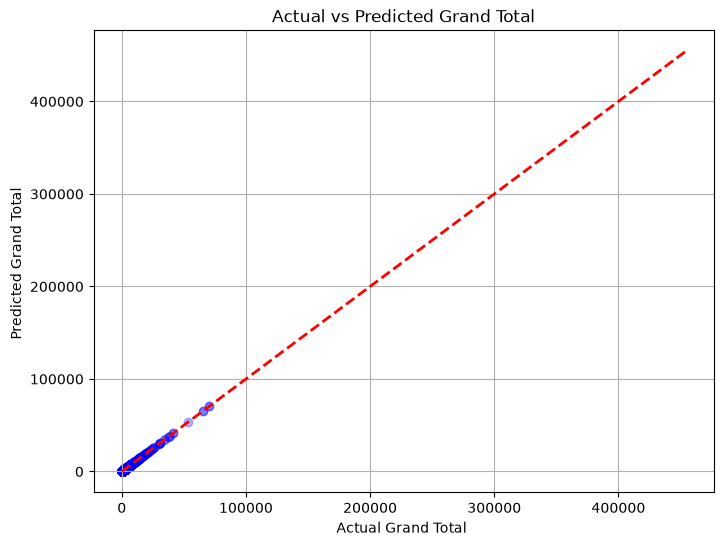

In [10]:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.xlabel("Actual Grand Total ")
plt.ylabel("Predicted Grand Total ")
plt.title("Actual vs Predicted Grand Total")
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', lw=2)
plt.grid(True)
plt.show()

### Test model

In [11]:

sample_order = X_train.iloc[0].copy()
sample_order['sub_total'] = 1500.0
sample_order['discount_amount'] = 100.0
sample_order['shipping_amount'] = 50.0
sample_order['total_qty_ordered'] = 2
sample_array = sample_order.values.reshape(1, -1)
sample_scaled = scaler.transform(sample_array)
predicted_total = lr_model.predict(sample_scaled)

print("=" * 40)
print(" LIVE SIMULATION TEST RESULT ")
print("=" * 40)
print(f"New Order Subtotal: 1500")
print(f"Model Predicted Grand Total: {predicted_total[0]:.2f}")
print("=" * 40)

 LIVE SIMULATION TEST RESULT 
New Order Subtotal: 1500
Model Predicted Grand Total: 1472.93


c:\Users\hp\Desktop\Machine_Learning\ml_env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [12]:
import pickle
pickle.dump(lr_model, open('saved_models/linear_regression_model.pkl', 'wb'))